In [3]:
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [18]:
import pandas as pd

df = pd.read_csv("books_raw.csv")
df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [19]:
df.shape

(200, 9)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         200 non-null    str  
 1   category      200 non-null    str  
 2   price         200 non-null    str  
 3   rating        200 non-null    int64
 4   availability  200 non-null    str  
 5   description   199 non-null    str  
 6   upc           200 non-null    str  
 7   num_reviews   200 non-null    int64
 8   product_url   200 non-null    str  
dtypes: int64(2), str(7)
memory usage: 14.2 KB


In [21]:
max_books = 200

In [23]:
df = pd.read_csv("books_raw.csv")

In [28]:
import os

os.makedirs("../data/raw/processed", exist_ok=True)

In [27]:
df.to_csv("../data/processed/books_cleaned.csv", index=False)

In [32]:
plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [34]:
df = pd.read_csv("books_raw.csv")

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [36]:
df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         200 non-null    str  
 1   category      200 non-null    str  
 2   price         200 non-null    str  
 3   rating        200 non-null    int64
 4   availability  200 non-null    str  
 5   description   199 non-null    str  
 6   upc           200 non-null    str  
 7   num_reviews   200 non-null    int64
 8   product_url   200 non-null    str  
dtypes: int64(2), str(7)
memory usage: 14.2 KB


In [38]:
print("Total records:", len(df))

Total records: 200


In [39]:
df.isnull().sum()

title           0
category        0
price           0
rating          0
availability    0
description     1
upc             0
num_reviews     0
product_url     0
dtype: int64

In [40]:
print("Duplicate UPCs:", df.duplicated(subset="upc").sum())

Duplicate UPCs: 0


In [41]:
df.describe(include="all")

,title,category,price,rating,availability,description,upc,num_reviews,product_url
count,200,200,200,200.000000,200,199,200,200.0,200
unique,200,36,196,NaN,11,199,200,NaN,200
top,It's Only the Himalayas,Default,£33.34,NaN,In stock (16 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,NaN,https://books.toscrape.com/catalogue/its-only-...
freq,1,31,2,NaN,84,1,1,NaN,1
mean,NaN,NaN,NaN,2.865000,NaN,NaN,NaN,0.0,NaN
std,NaN,NaN,NaN,1.451658,NaN,NaN,NaN,0.0,NaN
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.0,NaN
25%,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,0.0,NaN
50%,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,0.0,NaN
75%,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.0,NaN


In [42]:
df.describe(include="all")

,title,category,price,rating,availability,description,upc,num_reviews,product_url
count,200,200,200,200.000000,200,199,200,200.0,200
unique,200,36,196,NaN,11,199,200,NaN,200
top,It's Only the Himalayas,Default,£33.34,NaN,In stock (16 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,NaN,https://books.toscrape.com/catalogue/its-only-...
freq,1,31,2,NaN,84,1,1,NaN,1
mean,NaN,NaN,NaN,2.865000,NaN,NaN,NaN,0.0,NaN
std,NaN,NaN,NaN,1.451658,NaN,NaN,NaN,0.0,NaN
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.0,NaN
25%,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,0.0,NaN
50%,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,0.0,NaN
75%,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.0,NaN


In [43]:
clean_df = df.copy()

In [44]:
text_columns = ["title", "category", "availability", "description"]

for col in text_columns:
    clean_df[col] = clean_df[col].fillna("").str.strip()

In [45]:
clean_df = clean_df.drop_duplicates(subset="upc")

In [46]:
print("Remaining records:", len(clean_df))
print("Duplicate UPCs:", clean_df.duplicated(subset="upc").sum())

Remaining records: 200
Duplicate UPCs: 0


In [47]:
clean_df["description"] = clean_df["description"].replace("", "No description available")

In [48]:
clean_df["description"].isnull().sum()

np.int64(0)

In [49]:
clean_df["price"] = (
    clean_df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

In [50]:
clean_df["price"].head()
clean_df["price"].dtype

dtype('float64')

In [51]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [52]:
clean_df[["availability", "stock_count"]].head()

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19.0
1,In stock (19 available) In stock In stock In s...,19.0
2,In stock (19 available) In stock In stock In s...,19.0
3,In stock (19 available) In stock In stock In s...,19.0
4,In stock (19 available) In stock In stock In s...,19.0


In [53]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    str    
 1   category      200 non-null    str    
 2   price         200 non-null    float64
 3   rating        200 non-null    int64  
 4   availability  200 non-null    str    
 5   description   200 non-null    str    
 6   upc           200 non-null    str    
 7   num_reviews   200 non-null    int64  
 8   product_url   200 non-null    str    
 9   stock_count   200 non-null    float64
dtypes: float64(2), int64(2), str(6)
memory usage: 15.8 KB


In [56]:
clean_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    str    
 1   category      200 non-null    str    
 2   price         200 non-null    float64
 3   rating        200 non-null    int64  
 4   availability  200 non-null    str    
 5   description   200 non-null    str    
 6   upc           200 non-null    str    
 7   num_reviews   200 non-null    int64  
 8   product_url   200 non-null    str    
 9   stock_count   200 non-null    float64
dtypes: float64(2), int64(2), str(6)
memory usage: 15.8 KB


In [59]:
clean_df["price"].dtype

dtype('float64')

In [60]:
clean_df["price"].head(10)

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
5    35.02
6    52.29
7    17.46
8    20.66
9    13.99
Name: price, dtype: float64

In [61]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")
    .astype(int)
)

In [62]:
clean_df[["availability", "stock_count"]].head()

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19
1,In stock (19 available) In stock In stock In s...,19
2,In stock (19 available) In stock In stock In s...,19
3,In stock (19 available) In stock In stock In s...,19
4,In stock (19 available) In stock In stock In s...,19


In [63]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    str    
 1   category      200 non-null    str    
 2   price         200 non-null    float64
 3   rating        200 non-null    int64  
 4   availability  200 non-null    str    
 5   description   200 non-null    str    
 6   upc           200 non-null    str    
 7   num_reviews   200 non-null    int64  
 8   product_url   200 non-null    str    
 9   stock_count   200 non-null    int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 15.8 KB


In [64]:
clean_df[clean_df["availability"].str.extract(r"(\d+)")[0].isna()][["availability"]]

,availability


In [65]:
clean_df["availability"].unique()

<StringArray>
['In stock (19 available) In stock In stock In stock In stock In stock In stock',
          'In stock (19 available) In stock In stock In stock In stock In stock',
                   'In stock (20 available) In stock In stock In stock In stock',
 'In stock (17 available) In stock In stock In stock In stock In stock In stock',
 'In stock (18 available) In stock In stock In stock In stock In stock In stock',
 'In stock (16 available) In stock In stock In stock In stock In stock In stock',
                            'In stock (20 available) In stock In stock In stock',
                                     'In stock (20 available) In stock In stock',
                                              'In stock (20 available) In stock',
                                                       'In stock (22 available)',
 'In stock (15 available) In stock In stock In stock In stock In stock In stock']
Length: 11, dtype: str

In [66]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)")[0]
)

clean_df["stock_count"] = pd.to_numeric(
    clean_df["stock_count"],
    errors="coerce"
).fillna(0).astype(int)

In [70]:
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"\((\d+)\s+available\)", expand=False)
)

clean_df["stock_count"] = pd.to_numeric(
    clean_df["stock_count"],
    errors="coerce"
).fillna(0).astype(int)

In [71]:
clean_df[["availability", "stock_count"]].head(10)

,availability,stock_count
0,In stock (19 available) In stock In stock In s...,19
1,In stock (19 available) In stock In stock In s...,19
2,In stock (19 available) In stock In stock In s...,19
3,In stock (19 available) In stock In stock In s...,19
4,In stock (19 available) In stock In stock In s...,19
5,In stock (19 available) In stock In stock In s...,19
6,In stock (19 available) In stock In stock In s...,19
7,In stock (19 available) In stock In stock In s...,19
8,In stock (19 available) In stock In stock In s...,19
9,In stock (19 available) In stock In stock In s...,19


In [72]:
clean_df = clean_df[clean_df["title"] != "title"].reset_index(drop=True)

In [73]:
print(clean_df.shape)

(200, 10)


In [74]:
clean_df["description_word_count"] = clean_df["description"].apply(
    lambda x: len(str(x).split())
)

In [75]:
clean_df[["description", "description_word_count"]].head()

,description,description_word_count
0,"“Wherever you go, whatever you do, just . . . ...",230
1,Libertarianism isn't about winning elections; ...,195
2,"Andrew Barger, award-winning author and engine...",283
3,"Part fact, part fiction, Tyehimba Jess's much ...",249
4,This is the never-before-told story of the mus...,163


In [76]:
clean_df["price_band"] = pd.cut(
    clean_df["price"],
    bins=[0, 20, 35, 50, float("inf")],
    labels=["Low", "Medium", "High", "Premium"]
)

In [77]:
clean_df[["price", "price_band"]].head()

,price,price_band
0,45.17,High
1,51.33,Premium
2,37.59,High
3,23.88,Medium
4,57.25,Premium


In [78]:
clean_df["affordability_score"] = (
    clean_df["price"].max() - clean_df["price"]
)

In [79]:
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"]
).round(3)

In [80]:
clean_df["recommended"] = (
    (clean_df["rating"] >= 4) &
    (clean_df["price"] <= clean_df["price"].median())
)

In [81]:
clean_df.head()

,title,category,price,rating,availability,description,upc,num_reviews,product_url,stock_count,description_word_count,price_band,affordability_score,value_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,High,14.47,0.044,False
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,Premium,8.31,0.039,False
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,High,22.05,0.027,False
3,Olio,Poetry,23.88,1,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,35.76,0.042,False
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,Premium,2.39,0.052,False


In [82]:
clean_df["rating"].dtype

dtype('int64')

In [83]:
clean_df["rating"].isna().sum()

np.int64(0)

In [84]:
clean_df = clean_df.dropna(subset=["rating"]).reset_index(drop=True)

In [85]:
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"]
).round(3)

In [86]:
clean_df["rating"].isna().sum()

np.int64(0)

In [87]:
clean_df["recommended"] = (
    (clean_df["rating"] >= 4) &
    (clean_df["price"] <= clean_df["price"].median())
)

In [88]:
clean_df[["title", "rating", "price", "recommended"]].head()

,title,rating,price,recommended
0,It's Only the Himalayas,2,45.17,False
1,Libertarianism for Beginners,2,51.33,False
2,Mesaerion: The Best Science Fiction Stories 18...,1,37.59,False
3,Olio,1,23.88,False
4,Our Band Could Be Your Life: Scenes from the A...,3,57.25,False


In [90]:
clean_df.to_csv("books_cleaned.csv", index=False)

In [91]:
import os

os.path.exists("../data/processed/books_cleaned.csv")

True

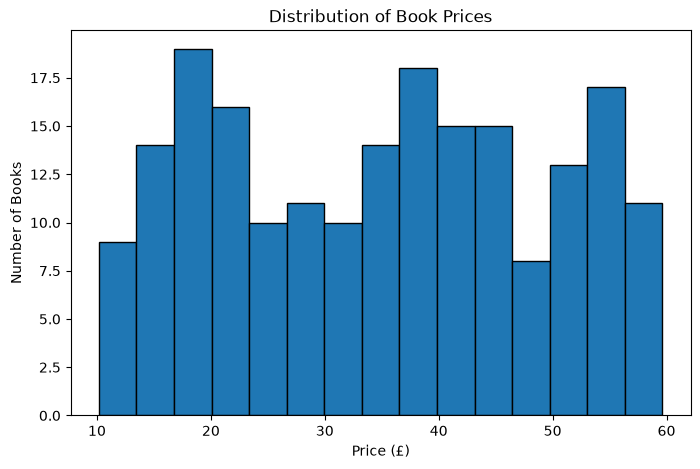

In [93]:
plt.figure(figsize=(8,5))

plt.hist(clean_df["price"], bins=15, edgecolor="black")

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [95]:
import os

os.path.exists("price_distribution.png")

True

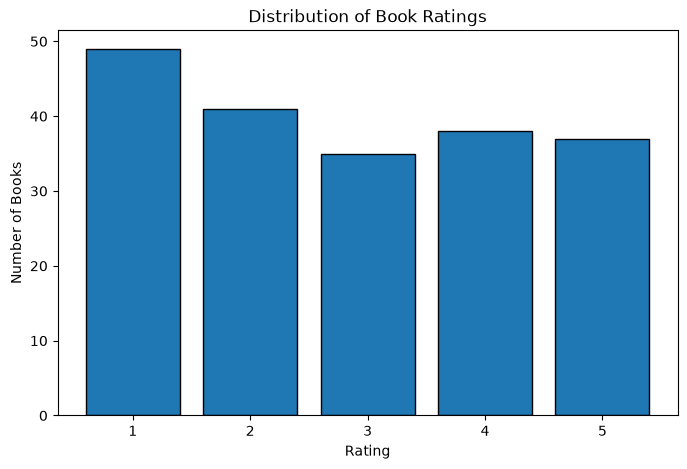

In [96]:
plt.figure(figsize=(8,5))

rating_counts = clean_df["rating"].value_counts().sort_index()

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.savefig("rating_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

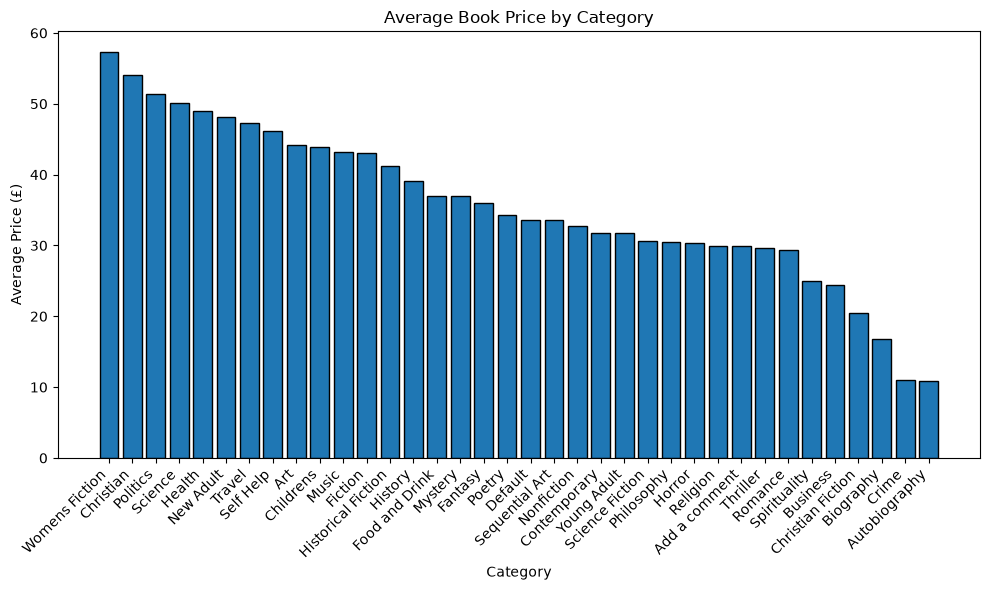

In [97]:
avg_price = (
    clean_df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(
    avg_price.index,
    avg_price.values,
    edgecolor="black"
)

plt.title("Average Book Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("average_price_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

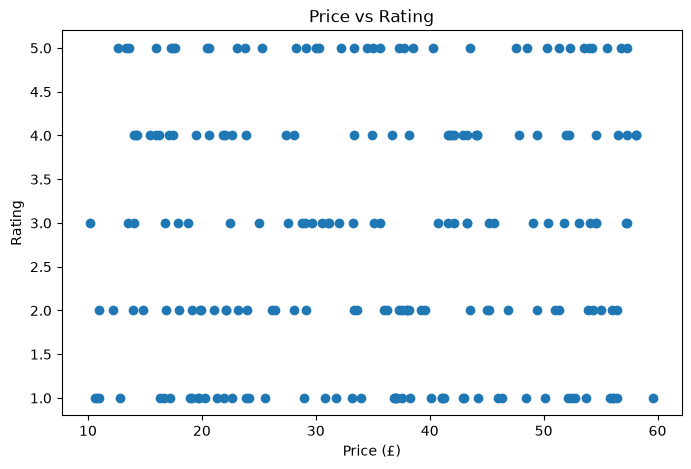

In [98]:
plt.figure(figsize=(8,5))

plt.scatter(
    clean_df["price"],
    clean_df["rating"]
)

plt.title("Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.savefig("price_vs_rating.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

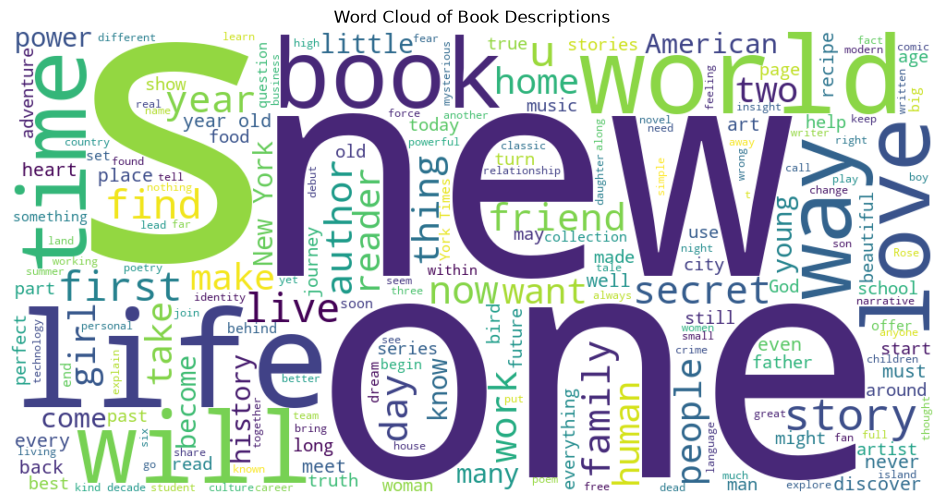

In [99]:
from wordcloud import WordCloud

text = " ".join(clean_df["description"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")

plt.savefig("wordcloud.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [100]:
print("Dataset Shape:", clean_df.shape)

print("\nAverage Price: £", round(clean_df["price"].mean(), 2))
print("Median Price: £", round(clean_df["price"].median(), 2))
print("Minimum Price: £", clean_df["price"].min())
print("Maximum Price: £", clean_df["price"].max())

print("\nAverage Rating:", round(clean_df["rating"].mean(), 2))
print("Highest Rating:", clean_df["rating"].max())

Dataset Shape: (200, 15)

Average Price: £ 34.8
Median Price: £ 35.64
Minimum Price: £ 10.16
Maximum Price: £ 59.64

Average Rating: 2.86
Highest Rating: 5


In [101]:
clean_df["rating"].value_counts().sort_index()

rating
1    49
2    41
3    35
4    38
5    37
Name: count, dtype: int64

In [103]:
clean_df["recommended"].value_counts()

recommended
False    162
True      38
Name: count, dtype: int64

In [105]:
   clean_df["category"].value_counts()

category
Default               31
Sequential Art        23
Nonfiction            20
Young Adult           10
Fantasy               10
Poetry                 9
Romance                9
Food and Drink         9
Fiction                9
Add a comment          7
Science Fiction        5
History                5
Mystery                5
Childrens              5
Historical Fiction     5
Business               4
Music                  3
Thriller               3
Philosophy             3
New Adult              3
Travel                 2
Spirituality           2
Horror                 2
Self Help              2
Science                2
Religion               2
Politics               1
Art                    1
Contemporary           1
Health                 1
Christian              1
Crime                  1
Christian Fiction      1
Womens Fiction         1
Biography              1
Autobiography          1
Name: count, dtype: int64

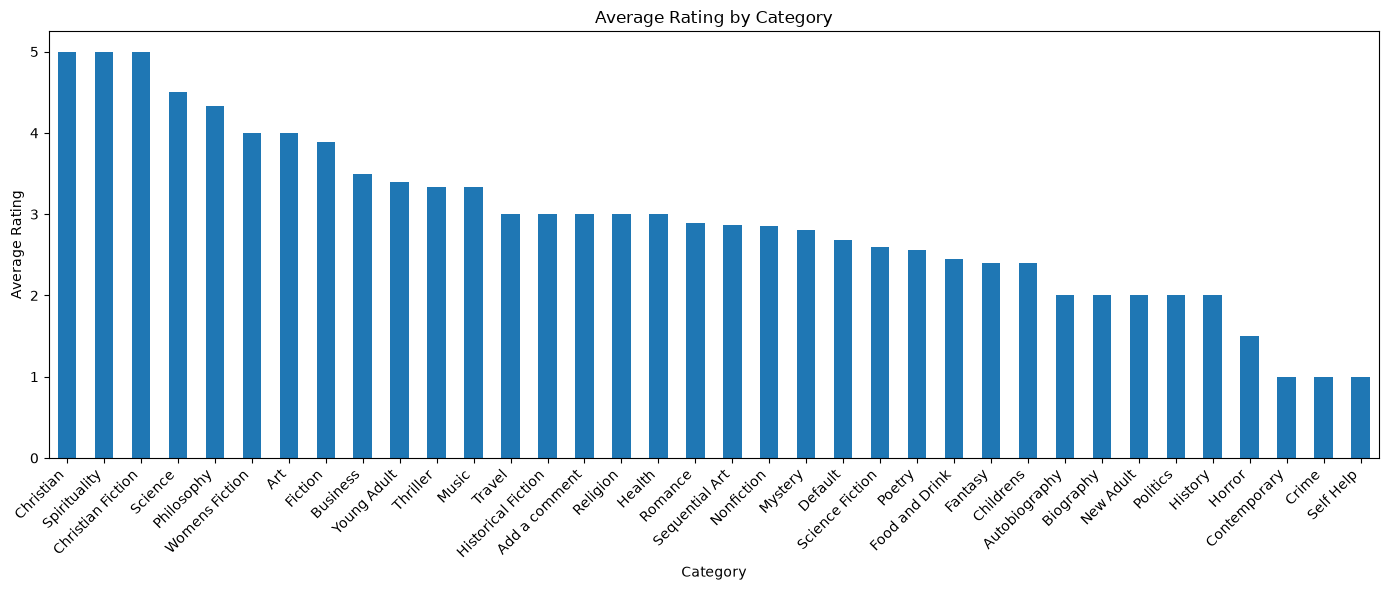

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the cleaned dataset
df = pd.read_csv("books_cleaned.csv")

# Calculate average rating for each category
category_rating = df.groupby("category")["rating"].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(14,6))
category_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

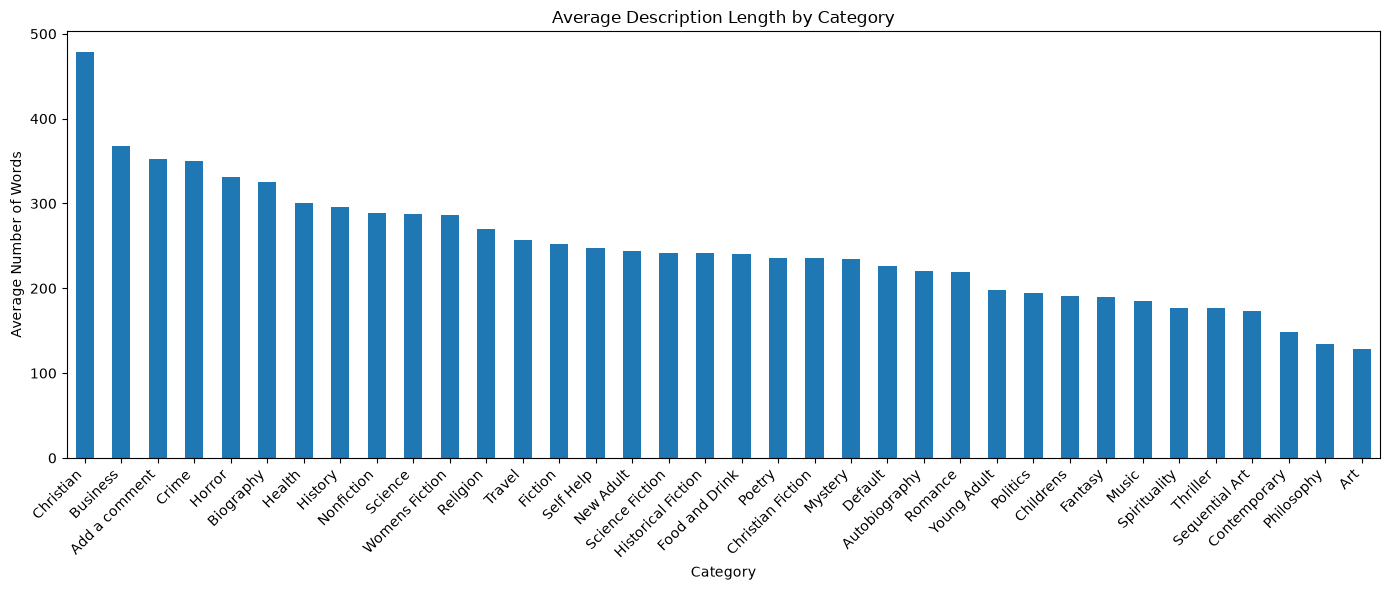

In [109]:
import matplotlib.pyplot as plt

# Average description length by category
category_desc = (
    df.groupby("category")["description_word_count"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))
category_desc.plot(kind="bar")

plt.title("Average Description Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
the analysis of the scrapaed book dataset shows that the book are available in a wide range of price and rating across differ categoris.
Most book prices fall between £15 and £55, overall low and hihg rating books are avaliable nearle number of book are same.
avgeare price high women's fiction , christian and politics.
avgera price high book demand top three is christian high rating this book good book. 
i think womens fiction low one fact is price.
no releation show in number of word t and rating releation.